In [1]:
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Connect to SQL Server
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=localhost;'
    'DATABASE=SaaS_Customer_Analytics;'
    'Trusted_Connection=yes;'
)

# Load all data from SQL Server
query = """
SELECT 
    c.customer_id, c.gender, c.senior_citizen,
    c.partner, c.dependents,
    s.internet_service, s.online_security,
    s.tech_support, s.streaming_tv,
    s.phone_service, s.multiple_lines,
    ct.contract_type, ct.payment_method,
    ct.paperless_billing,
    m.tenure_months, m.monthly_charges,
    m.total_charges, m.churn_flag
FROM dim_customer c
JOIN dim_service s ON c.customer_id = s.customer_id
JOIN dim_contract ct ON c.customer_id = ct.customer_id
JOIN fact_customer_metrics m ON c.customer_id = m.customer_id
"""

df = pd.read_sql(query, conn)
print(f"✅ Loaded {len(df)} records from SQL Server")
print(f"\nColumns: {list(df.columns)}")
df.head()

✅ Loaded 7043 records from SQL Server

Columns: ['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'tech_support', 'streaming_tv', 'phone_service', 'multiple_lines', 'contract_type', 'payment_method', 'paperless_billing', 'tenure_months', 'monthly_charges', 'total_charges', 'churn_flag']


,customer_id,gender,senior_citizen,partner,dependents,internet_service,online_security,tech_support,streaming_tv,phone_service,multiple_lines,contract_type,payment_method,paperless_billing,tenure_months,monthly_charges,total_charges,churn_flag
0,0002-ORFBO,Female,False,Yes,Yes,DSL,No,Yes,Yes,Yes,No,One year,Mailed check,Yes,9,65.6,593.30,False
1,0003-MKNFE,Male,False,No,No,DSL,No,No,No,Yes,Yes,Month-to-month,Mailed check,No,9,59.9,542.40,False
2,0004-TLHLJ,Male,False,No,No,Fiber optic,No,No,No,Yes,No,Month-to-month,Electronic check,Yes,4,73.9,280.85,True
3,0011-IGKFF,Male,True,Yes,No,Fiber optic,No,No,Yes,Yes,No,Month-to-month,Electronic check,Yes,13,98.0,1237.85,True
4,0013-EXCHZ,Female,True,Yes,No,Fiber optic,No,Yes,Yes,Yes,No,Month-to-month,Mailed check,Yes,3,83.9,267.40,True


In [2]:
print("📊 Dataset Shape:", df.shape)
print("\n📋 Data Types:")
print(df.dtypes)
print("\n📈 Basic Statistics:")
df.describe()

📊 Dataset Shape: (7043, 18)

📋 Data Types:
customer_id           object
gender                object
senior_citizen          bool
partner               object
dependents            object
internet_service      object
online_security       object
tech_support          object
streaming_tv          object
phone_service         object
multiple_lines        object
contract_type         object
payment_method        object
paperless_billing     object
tenure_months          int64
monthly_charges      float64
total_charges        float64
churn_flag              bool
dtype: object

📈 Basic Statistics:


,tenure_months,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992
std,24.559481,30.090047,2266.730170
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


📊 Total Customers: 7043
❌ Churned Customers: 1869
✅ Active Customers: 5174
📉 Overall Churn Rate: 26.5%


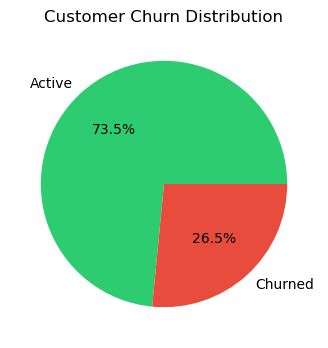

In [3]:
# Overall churn rate
churn_counts = df['churn_flag'].value_counts()
churn_rate = df['churn_flag'].mean() * 100

print(f"📊 Total Customers: {len(df)}")
print(f"❌ Churned Customers: {churn_counts[1]}")
print(f"✅ Active Customers: {churn_counts[0]}")
print(f"📉 Overall Churn Rate: {churn_rate:.1f}%")

# Plot
plt.figure(figsize=(6,4))
plt.pie(churn_counts, 
        labels=['Active', 'Churned'], 
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution')
plt.show()

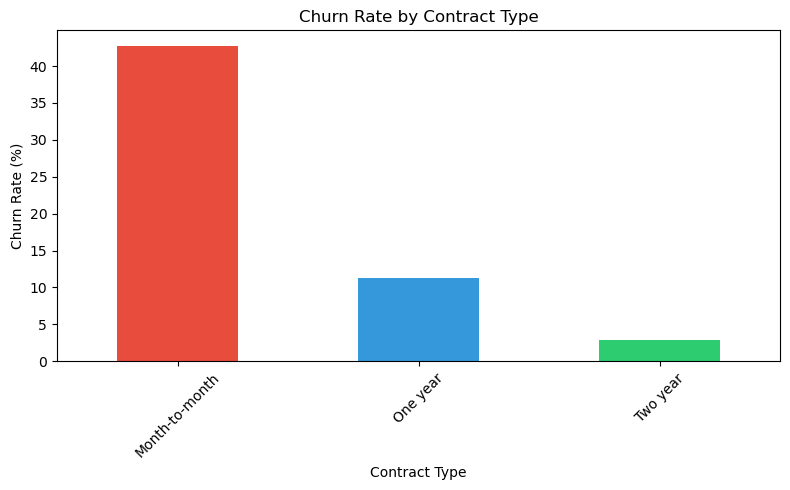

contract_type
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: churn_flag, dtype: float64


In [4]:
plt.figure(figsize=(8,5))
contract_churn = df.groupby('contract_type')['churn_flag'].mean() * 100
contract_churn.plot(kind='bar', color=['#e74c3c','#3498db','#2ecc71'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(contract_churn)

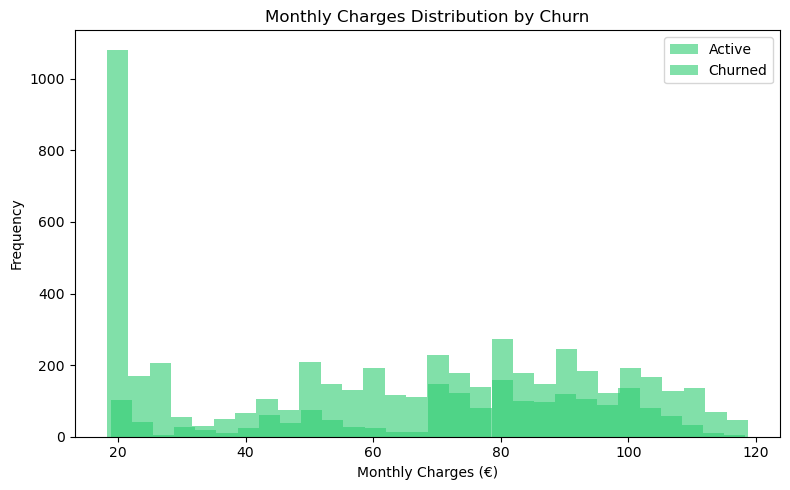

In [5]:
plt.figure(figsize=(8,5))
df.groupby('churn_flag')['monthly_charges'].plot(
    kind='hist', alpha=0.6, bins=30,
    color=['#2ecc71','#e74c3c'])
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges (€)')
plt.legend(['Active', 'Churned'])
plt.tight_layout()
plt.show()

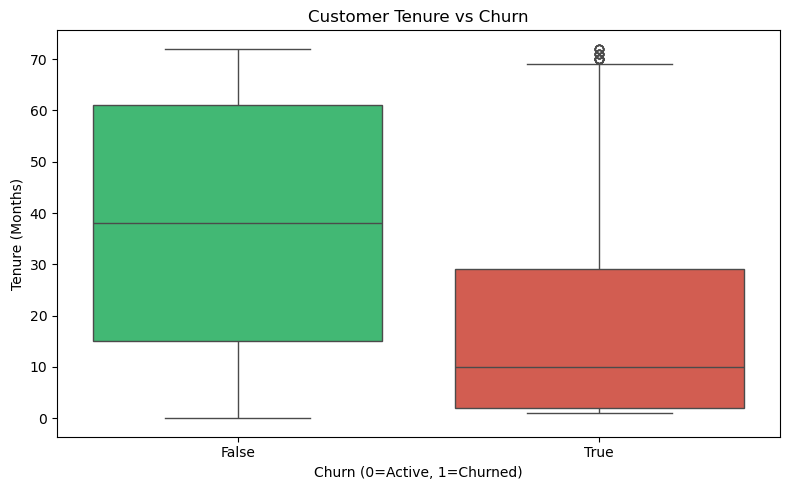

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn_flag', y='tenure_months', data=df,
            palette=['#2ecc71','#e74c3c'])
plt.title('Customer Tenure vs Churn')
plt.xlabel('Churn (0=Active, 1=Churned)')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

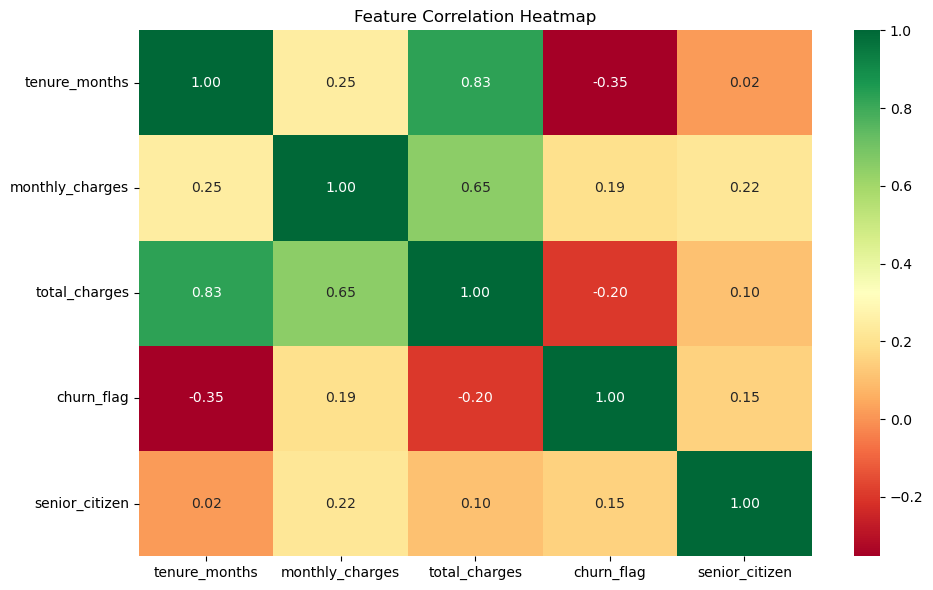

In [7]:
plt.figure(figsize=(10,6))
numeric_cols = ['tenure_months','monthly_charges',
                'total_charges','churn_flag','senior_citizen']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()